# Bài toán Logistic Regression
Một nhóm 20 sinh viên dành thời gian trong khoảng từ 0 đến 6 giờ cho việc ôn thi. Thời gian ôn thi này ảnh hưởng đến xác suất sinh viên vượt qua kỳ thi như thế nào?

Kết quả thu được như sau

| Hours | Pass | Hours | Pass |
| :---: | :---: | :---: | :---: |
| .5 | 0 | 2.75 | 1 |
| .75 | 0 | 3 | 0 |
| 1 | 0 | 3.25 | 1 |
| 1.25 | 0 | 3.5 | 0 |
| 1.5 | 0 | 4 | 1 |
| 1.75 | 0 | 4.25 | 1 |
| 1.75 | 1 | 4.5 | 1 |
| 2 | 0 | 4.75 | 1 |
| 2.25 | 1 | 5 | 1 |
| 2.5 | 0 | 5.5 | 1 |

In [106]:
import numpy as np
import matplotlib.pyplot as plt

In [107]:
np.random.seed(0)
# Hours
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
# Pass
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

## Data Visualization

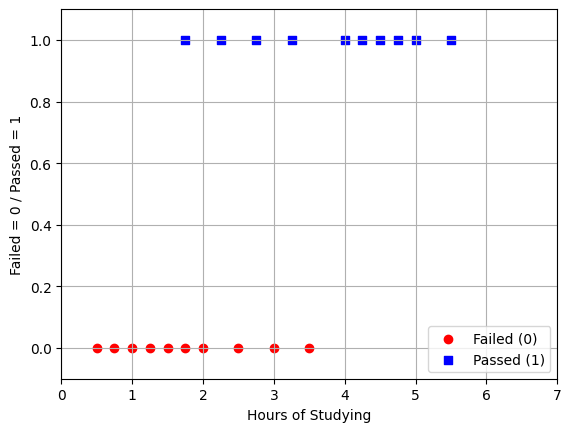

In [108]:
import matplotlib.pyplot as plt
import numpy as np

X_flat = np.array(X).flatten()
y_flat = np.array(y).flatten()

X_fail = X_flat[y == 0]
y_fail = y_flat[y == 0]

X_pass = X_flat[y == 1]
y_pass = y_flat[y == 1]

plt.scatter(X_fail, y_fail, color='red', marker='o', label='Failed (0)') 
plt.scatter(X_pass, y_pass, color='blue', marker='s', label='Passed (1)')

plt.axis([0.0, 7.0, -0.1 ,1.1])
plt.grid()
plt.xlabel('Hours of Studying')
plt.ylabel('Failed = 0 / Passed = 1')
plt.legend()
plt.show()

## Các hàm cần thiết cho logistic sigmoid regression

In [109]:
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

In [110]:
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:,i].reshape(d,1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi-zi)*xi
            count+=1
            # stopping criteria
            if count%check_w_after == 0:
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

Tìm w để $$P(y|X;w) max$$

$$w = argmax P(y|X;w) $$

In [111]:
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print(w[-1])

[[-4.09922307]
 [ 1.55900124]]


In [112]:
print(sigmoid(np.dot(w[-1].T, X)))

[[0.03490076 0.05069167 0.07308614 0.10428717 0.14670004 0.20246303
  0.20246303 0.27264966 0.35629757 0.44974032 0.54686957 0.64055657
  0.72462709 0.79531748 0.89442712 0.92598102 0.94864549 0.96463519
  0.97577349 0.98874121]]


## Từ đó, ta có được Prediction dựa trên dữ liệu và hàm sigmoid tìm được

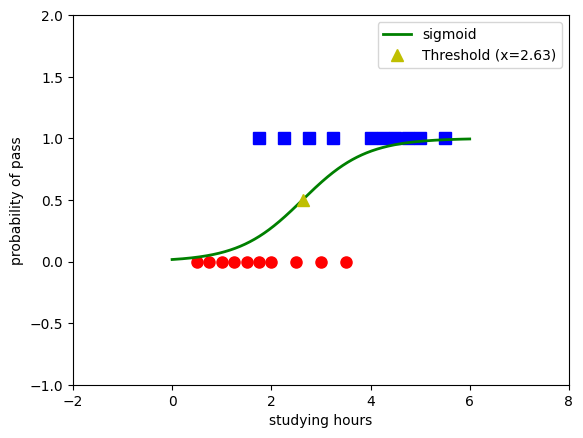

In [113]:
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2, label='sigmoid')
plt.plot(threshold, .5, 'y^', markersize = 8, label=f'Threshold (x={threshold:.2f})')
plt.xlabel('studying hours')
plt.ylabel('probability of pass')
plt.legend()
plt.show()